# Business Analytics Case Study
## LINDSLY MUYONDA
## WEEK 5 PROJECT
## Telco Customer Churn Dataset

In [1]:
!pip install pandas matplotlib seaborn numpy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = {"No": "#111111", "Yes": "#FF3B8D"}   # black = stayed, pink = churned

In [3]:
import os

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
df = pd.read_csv(os.path.join(downloads_path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges:", df['TotalCharges'].isnull().sum())

df = df.dropna(subset=['TotalCharges']).copy()
print("Shape after cleaning:", df.shape)

df.info()

Missing TotalCharges: 11
Shape after cleaning: (7032, 21)
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   ob

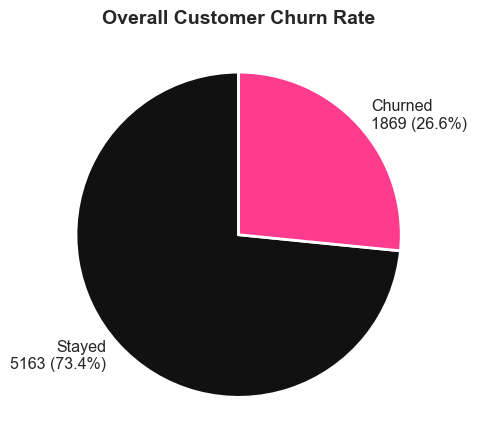

In [5]:
fig, ax = plt.subplots(figsize=(5,5))
counts = df['Churn'].value_counts()

ax.pie(
    counts,
    labels=[f"Stayed\n{counts['No']} ({counts['No']/len(df)*100:.1f}%)",
            f"Churned\n{counts['Yes']} ({counts['Yes']/len(df)*100:.1f}%)"],
    colors=[PALETTE['No'], PALETTE['Yes']],
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
ax.set_title("Overall Customer Churn Rate", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("chart1_churn_pie.png", dpi=150)
plt.show()

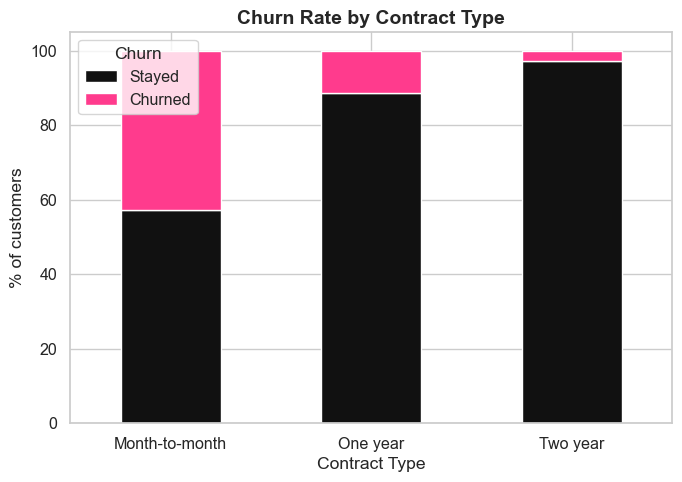

In [6]:
fig, ax = plt.subplots(figsize=(7,5))
ct = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
ct = ct.loc[['Month-to-month', 'One year', 'Two year']]

ct[['No','Yes']].plot(kind='bar', stacked=True, ax=ax, color=[PALETTE['No'], PALETTE['Yes']])
ax.set_ylabel("% of customers")
ax.set_xlabel("Contract Type")
ax.set_title("Churn Rate by Contract Type", fontsize=14, fontweight='bold')
ax.legend(title="Churn", labels=["Stayed", "Churned"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart2_churn_by_contract.png", dpi=150)
plt.show()

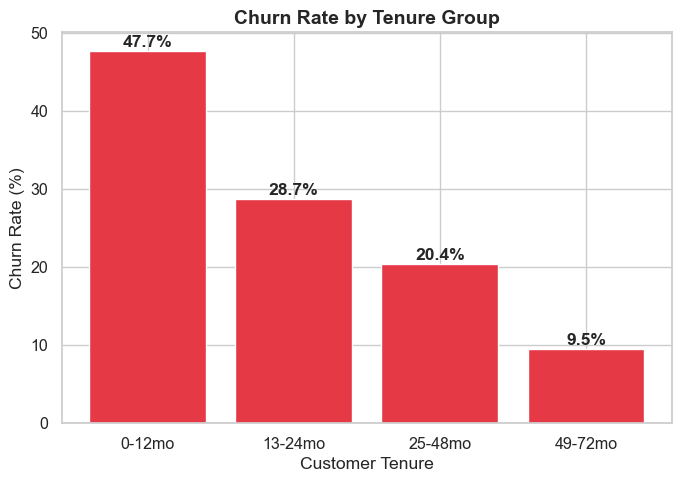

In [7]:
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                              labels=['0-12mo','13-24mo','25-48mo','49-72mo'])

tb = df.groupby('tenure_bucket', observed=True)['Churn'].apply(lambda x: (x=='Yes').mean()*100)

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(tb.index.astype(str), tb.values, color='#E63946')
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Customer Tenure")
ax.set_title("Churn Rate by Tenure Group", fontsize=14, fontweight='bold')

for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.1f}%",
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("chart3_churn_by_tenure.png", dpi=150)
plt.show()

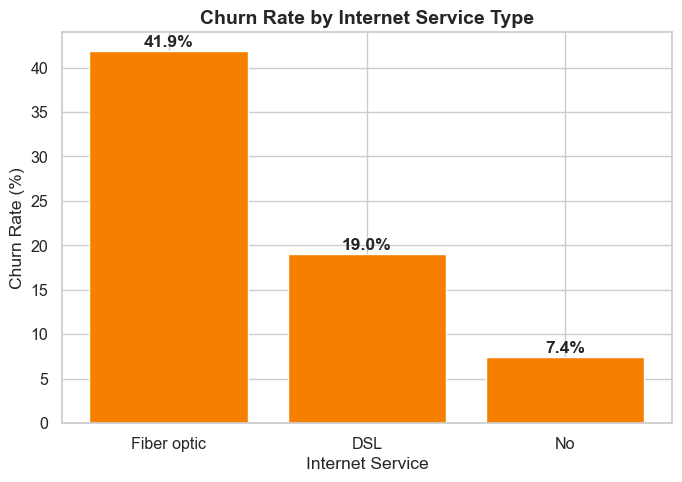

In [8]:
fig, ax = plt.subplots(figsize=(7,5))
isv = df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)

bars = ax.bar(isv.index, isv.values, color='#F77F00')
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Internet Service")
ax.set_title("Churn Rate by Internet Service Type", fontsize=14, fontweight='bold')

for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.1f}%",
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("chart4_churn_by_internet.png", dpi=150)
plt.show()

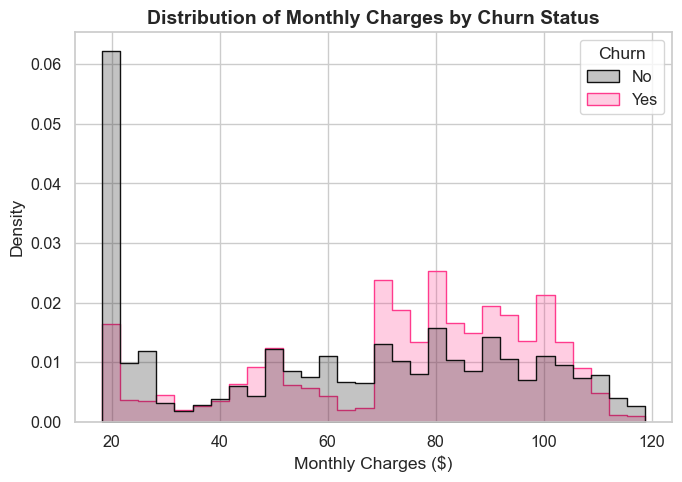

In [9]:
fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, palette=PALETTE,
             element='step', stat='density', common_norm=False, ax=ax)
ax.set_title("Distribution of Monthly Charges by Churn Status", fontsize=14, fontweight='bold')
ax.set_xlabel("Monthly Charges ($)")
plt.tight_layout()
plt.savefig("chart5_monthly_charges_dist.png", dpi=150)
plt.show()

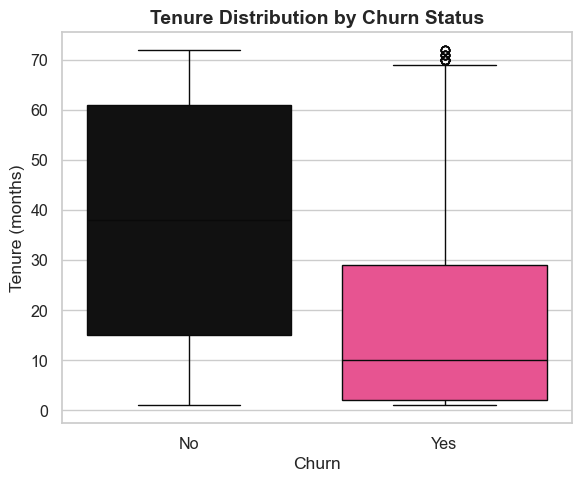

In [10]:
fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette=PALETTE, legend=False, ax=ax)
ax.set_title("Tenure Distribution by Churn Status", fontsize=14, fontweight='bold')
ax.set_xlabel("Churn")
ax.set_ylabel("Tenure (months)")
plt.tight_layout()
plt.savefig("chart6_tenure_boxplot.png", dpi=150)
plt.show()

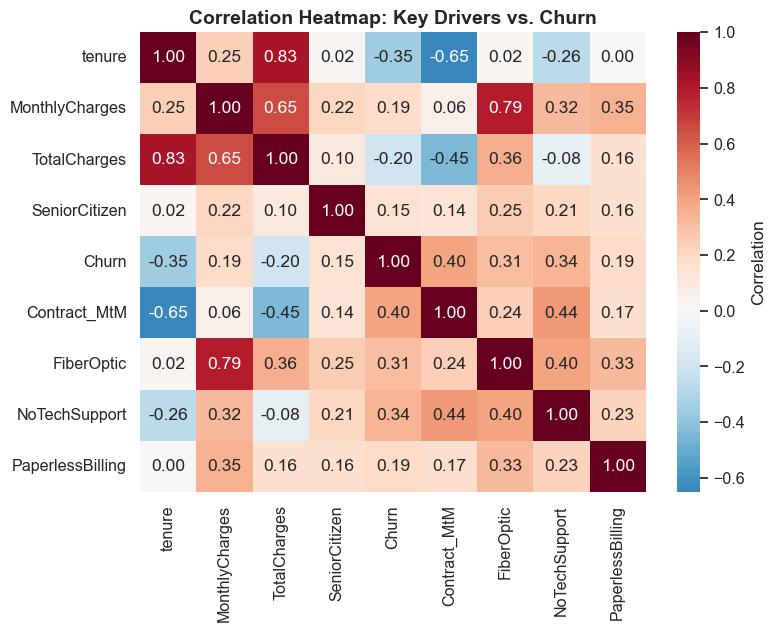

In [11]:
corr_df = df[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']].copy()
corr_df['Churn'] = (df['Churn'] == 'Yes').astype(int)
corr_df['Contract_MtM'] = (df['Contract'] == 'Month-to-month').astype(int)
corr_df['FiberOptic'] = (df['InternetService'] == 'Fiber optic').astype(int)
corr_df['NoTechSupport'] = (df['TechSupport'] == 'No').astype(int)
corr_df['PaperlessBilling'] = (df['PaperlessBilling'] == 'Yes').astype(int)

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(8,6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label':'Correlation'})
ax.set_title("Correlation Heatmap: Key Drivers vs. Churn", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("chart7_correlation_heatmap.png", dpi=150)
plt.show()

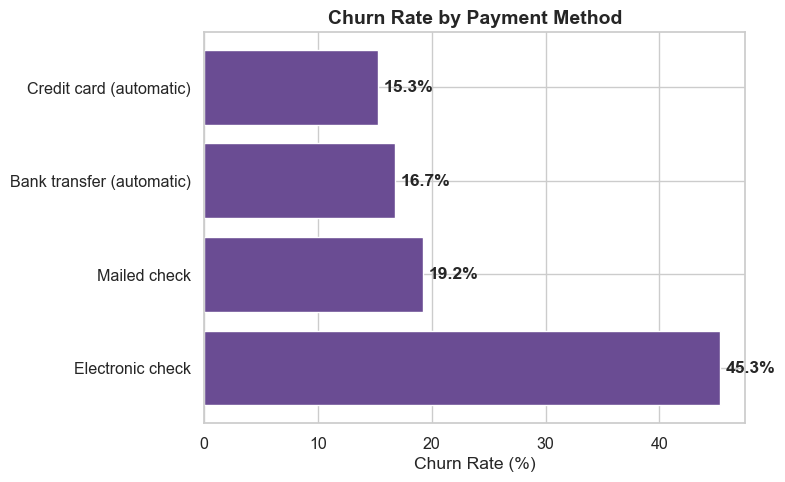

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
pm = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)

bars = ax.barh(pm.index, pm.values, color='#6A4C93')
ax.set_xlabel("Churn Rate (%)")
ax.set_title("Churn Rate by Payment Method", fontsize=14, fontweight='bold')

for b in bars:
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}%",
            va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("chart8_churn_by_payment.png", dpi=150)
plt.show()

In [13]:
churned = df[df['Churn'] == 'Yes']

print("Churned customers:", len(churned))
print("Monthly revenue at risk: $", round(churned['MonthlyCharges'].sum(), 2))
print("Annualized revenue at risk: $", round(churned['MonthlyCharges'].sum()*12, 2))

high_risk = df[(df['Contract']=='Month-to-month') &
               (df['InternetService']=='Fiber optic') &
               (df['PaymentMethod']=='Electronic check')]
print("\nHigh-risk segment size:", len(high_risk))
print("High-risk segment churn rate:", round((high_risk['Churn']=='Yes').mean()*100, 1), "%")

Churned customers: 1869
Monthly revenue at risk: $ 139130.85
Annualized revenue at risk: $ 1669570.2

High-risk segment size: 1307
High-risk segment churn rate: 60.4 %
